# 4. 多层感知机 (MLP) (上)

In [2]:
# 本章开始，会调用曾经的函数。
# 1. 开启自动重载
# %load_ext autoreload: 加载“自动重载”这个扩展插件。
# %autoreload 2: 设置重载模式为 模式 2。
# 模式说明：
#     %autoreload 0：禁用自动重载（默认状态）。
#     %autoreload 1：只重载那些用 %aimport 指定的模块。
#     %autoreload 2：最强模式。在你每次执行任何 Notebook 单元格之前，它都会自动检查所有已导入的模块。如果发现文件变了，它就立刻在内存里替换掉旧的代码。
%load_ext autoreload
%autoreload 2

# 2. 导入工具包
import d2l_utils as d2l

# 3. 验证
print(f"D2L Utils Version: {d2l.__version__}")
print(f"D2L Utils All: {d2l.__all__}")

D2L Utils Version: 0.1.0
D2L Utils All: ['DATA_ROOT', 'IS_WINDOWS', 'Accumulator', 'load_fashion_mnist', 'count_correct', 'cross_entropy', 'sgd', 'train_softmax', 'DataStreamVisualizer']


## 4.1 多层感知机的数学原理

### 一、 局限：线性模型的“天花板”

线性模型（如 Softmax 回归）本质上是在做**仿射变换（Affine Transformation）**。

1.  **数学上的单调性**：线性模型认为特征 $x_i$ 的增加对结果的影响要么恒正，要么恒负。
2.  **特征孤立性**：它很难处理特征之间的“化学反应”。
    *   *例子*：在预测房价时，如果“卧室多”且“在市中心”，价格会指数级暴涨。线性模型只能把这两个特征相加，无法表达这种**乘法/组合效应**。
3.  **几何直觉**：线性模型只能在空间中画“直线/超平面”。如果数据是像“阴阳鱼”一样交织在一起的，线性模型永远无法将它们分开。

---

### 二、 破局：从“浅”到“深”的结构演进

为了解决非线性问题，我们引入**隐藏层（Hidden Layer）**。

#### 1. 结构的定义
我们不再直接从输入映射到输出，而是增加了一个中间缓冲带：
*   **输入 $\mathbf{X}$** $\in \mathbb{R}^{n \times d}$（$n$ 个样本，$d$ 个特征）
*   **隐藏层 $\mathbf{H}$** $\in \mathbb{R}^{n \times h}$（$h$ 个隐藏单元/神经元）
*   **输出层 $\mathbf{O}$** $\in \mathbb{R}^{n \times q}$（$q$ 个分类目标）

#### 2. “线性堆叠”的数学陷阱（核心论点）
如果你只是简单地堆叠层：
$$\mathbf{H} = \mathbf{X} \mathbf{W}_1 + \mathbf{b}_1$$
$$\mathbf{O} = \mathbf{H} \mathbf{W}_2 + \mathbf{b}_2$$
**合并后：** $\mathbf{O} = (\mathbf{X} \mathbf{W}_1 + \mathbf{b}_1) \mathbf{W}_2 + \mathbf{b}_2 = \mathbf{X} (\mathbf{W}_1 \mathbf{W}_2) + (\mathbf{b}_1 \mathbf{W}_2 + \mathbf{b}_2)$
*   **结论**：多层线性算子等价于单层线性算子。**没有激活函数，深层网络只是一个“穿着马甲”的线性模型。**

---

### 三、 本质：激活函数是灵魂

激活函数 $\sigma$ 的引入，是为了打破层与层之间的线性嵌套，赋予模型**“空间折叠”**的能力。

**标准 MLP 公式：**
$$\mathbf{H} = \sigma(\mathbf{X} \mathbf{W}_1 + \mathbf{b}_1)$$
$$\mathbf{O} = \mathbf{H} \mathbf{W}_2 + \mathbf{b}_2$$

#### 为什么激活函数能奏效？
*   **非线性注入**：它在计算过程中引入了“弯折”或“阈值”，使得 $\mathbf{W}_1$ 和 $\mathbf{W}_2$ 无法合并。
*   **万能近似定理 (Universal Approximation Theorem)**：
    *   **核心思想**：即便只有一个隐藏层，只要给它**足够多**的神经元和**非线性激活函数**，MLP 理论上可以拟合任何连续函数。
    *   **工程启示**：如果你觉得模型学不会某个规律，通常有两个办法：
        1. 把隐藏层变**宽**（增加神经元数量）。
        2. 把网络变**深**（增加隐藏层层数）。

---

### 四、 工具：三大主流激活函数的深度对比

> 注意：ReLU 在 0 处是不可导的，但在工程实现上认为是 0。

| 函数 | 图形特征 (公式) | 导数 (Gradient) | 优缺点 | 适用场景 |
| :--- | :--- | :--- | :--- | :--- |
| **ReLU** | $f(x) = \max(0, x)$ | $1, \quad x > 0$<br>$0, \quad x < 0$ | **优**：计算极快，无梯度饱和。<br>**缺**：存在 Dead ReLU 问题。 | **默认首选**。几乎所有隐藏层。 |
| **Sigmoid** | $\sigma(x) = \frac{1}{1 + e^{-x}}$ | $\sigma(x) \cdot (1 - \sigma(x))$ | **优**：输出在 $(0, 1)$，平滑。<br>**缺**：梯度消失严重(两头平)，计算慢。 | 二分类**输出层**，极少用于隐藏层。 |
| **Tanh** | $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$ | $1 - \tanh^2(x)$ | **优**：零中心化，收敛比 Sigmoid 快。<br>**缺**：依然存在梯度饱和。 | **RNN** 或特定控制任务。 |

---

### 五、 总结：如何构建一个好的 MLP？

在实际操作中，设计一个 MLP 需要权衡三个维度：

1.  **宽度 (Width)**：隐藏层神经元的数量。增加宽度能增强模型对当前特征的提取能力。
2.  **深度 (Depth)**：隐藏层的层数。增加深度能让模型学习更抽象的特征（如从“边缘”到“形状”再到“物体”）。
3.  **激活选择**：
    *   隐藏层：统一用 **ReLU**。
    *   输出层：回归任务不用激活，分类任务配合 **Softmax**。

**一句话总结 MLP：**
MLP 通过**线性变换**（矩阵乘法）改变特征维度，通过**非线性激活**（激活函数）扭曲空间，从而在多维空间中编织出一张极其复杂的网，捕获数据中深层的规律。

## 4.2 多层感知机从零实现

> 数据集依旧是 Fashion-MNIST

> 核心在于**非线性**。

In [3]:
# 参数初始化：定义隐藏层
# 相比线性回归，MLP 多了一组权重和偏置。我们设定隐藏层有 256 个神经元。
import torch
from torch import Tensor

# 1. 定义网络规模
num_inputs: int = 784 # 28*28=784 像素
num_outputs: int = 10 # 10 个类别
num_hiddens: int = 256 # 隐藏层宽度

# 2. 初始化第一层参数 (输入 -> 隐藏)
# w1 形状: (784, 256)
w1: Tensor = torch.normal(0, 0.01, size=(num_inputs, num_hiddens), requires_grad=True)
b1: Tensor = torch.zeros(num_hiddens, requires_grad=True)

# 3. 初始化第二层参数 (隐藏 -> 输出)
# w2 形状: (256, 10)
w2: Tensor = torch.normal(0, 0.01, size=(num_hiddens, num_outputs), requires_grad=True)
b2: Tensor = torch.zeros(num_outputs, requires_grad=True)

# 将所有参数放入列表，方便后续优化器读取
params: list[Tensor] = [w1, b1, w2, b2]

In [4]:
# # 增加一个深度 (可选)
# # 1. 定义超参数
# num_inputs, num_outputs = 784, 10
# num_hiddens1, num_hiddens2 = 256, 128 # 两个隐藏层的宽度

# # 2. 初始化参数 (需注意形状对齐！)
# # 第一层：784 -> 256
# w1: Tensor = torch.normal(0, 0.01, size=(num_inputs, num_hiddens1), requires_grad=True)
# b1: Tensor = torch.zeros(num_hiddens1, requires_grad=True)

# # 第二层：256 -> 128
# w2: Tensor = torch.normal(0, 0.01, size=(num_hiddens1, num_hiddens2), requires_grad=True)
# b2: Tensor = torch.zeros(num_hiddens2, requires_grad=True)

# # 第三层：128 -> 10
# w3: Tensor = torch.normal(0, 0.01, size=(num_hiddens2, num_outputs), requires_grad=True)
# b3: Tensor = torch.zeros(num_outputs, requires_grad=True)

# # 将参数打包，给优化器用
# params: list[Tensor] = [w1, b1, w2, b2, w3, b3]

**原则**：**激活函数通常只加在隐藏层之后，输出层通常保持线性。**

In [5]:
# 定义激活函数 (ReLU)
# ReLU (Rectified Linear Unit) - 目前最主流，默认首选
# 公式: max(0, x)
def relu(X: Tensor) -> Tensor:
    """手动实现 ReLU 激活函数。
    
    Args:
        X: 输入张量。

    Returns:
        与 X 形状相同的张量，负数被置为 0。
    """
    # torch.zeros_like 创建一个形状和类型与 X 完全一样的全 0 张量
    a: Tensor = torch.zeros_like(X)
    return torch.max(X, a)

In [6]:
# 定义网络模型d2l.train_softmax(net, train_iter, test_iter, loss_fn, num_epochs, updater)
# 这里体现了数据流（Data Flow）的过程：输入 -> 展平 -> 隐藏层 -> 激活 -> 输出层。
def net(X: Tensor) -> Tensor:
    """定义多层感知机的前向传播逻辑。
    
    Args:
        X: 输入图像批次，形状为 (batch_size, 1, 28, 28)。

    Returns:
        未经过 Softmax 的原始输出 (Logits)，形状为 (batch_size, 10)。
    """
    # 1. 展平：将 (batch_size, 1, 28, 28) 转换为 (batch_size, 784)
    X = X.reshape((-1, num_inputs))

    # 2. 计算隐藏层: H = ReLU(Xw1 + b1)
    # 使用 matmul 进行矩阵乘法
    h: Tensor = relu(torch.matmul(X, w1) + b1)

    # 3. 计算输出层: Out = Hw2 + b2
    return torch.matmul(h, w2) + b2

In [7]:
# # 增加一个深度 (3层 MLP 模型)
# def net_deep(X: Tensor) -> Tensor:
#     # 展平
#     X = X.reshape((-1, num_inputs))

#     # 第一层运算 + 激活
#     H1: Tensor = relu(torch.matmul(X, w1) + b1)

#     # 第二层运算 + 激活
#     H2: Tensor = relu(torch.matmul(H1, w2) + b2)

#     # 输出层 (通常不加激活)
#     return torch.matmul(H2, w3) + b3

In [8]:
# 定义损失函数
# 可考虑沿用之前的 cross_entropy 函数，或用 PyTorch 官方的，确保数值稳定性。
from torch import nn
# reduction='none' 保持每个样本的损失，方便我们之前写的 Accumulator 记账
loss_fn = nn.CrossEntropyLoss(reduction='none')

In [9]:
# 训练模型
# 此处复用之前写好的函数 train_softmax 指挥函数等
import d2l_utils as d2l

# 设置超参数
num_epochs: int = 10
lr: float = 0.1
batch_size: int = 256

# 这里的 updater 是用手写的 sgd 函数封装的
# 我们需要传 params 进去
def updater(batch_size: int) -> None:
    """适配 train_softmax 接口的参数更新器。"""
    # 调用之前写的 sgd 函数
    d2l.sgd(params, lr, batch_size)

# 加载数据集
train_iter, test_iter = d2l.load_fashion_mnist(batch_size=batch_size)

# 执行训练
d2l.train_softmax(net, train_iter, test_iter, loss_fn, num_epochs, updater)

# # 增加一个深度 (不能与上面那个同时运行)
# d2l.train_softmax(net_deep, train_iter, test_iter, loss_fn, num_epochs, updater)

Dataset check complete at: /home/august/deepseek/pytorch_study/temp/data
开始训练，总轮数: 10。


/home/august/deepseek/pytorch_study/d2l_utils.py:348: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  metric.add(float(l.sum()), count_correct(y_hat, y), y.numel())


Epoch 1: Loss = 1.0405, Train Acc = 0.6447, Test Acc = 0.7599
Epoch 2: Loss = 0.5995, Train Acc = 0.7878, Test Acc = 0.7755
Epoch 3: Loss = 0.5191, Train Acc = 0.8171, Test Acc = 0.8157
Epoch 4: Loss = 0.4804, Train Acc = 0.8300, Test Acc = 0.7987
Epoch 5: Loss = 0.4540, Train Acc = 0.8399, Test Acc = 0.7995
Epoch 6: Loss = 0.4356, Train Acc = 0.8460, Test Acc = 0.8398
Epoch 7: Loss = 0.4172, Train Acc = 0.8519, Test Acc = 0.8431
Epoch 8: Loss = 0.4027, Train Acc = 0.8576, Test Acc = 0.8113
Epoch 9: Loss = 0.3930, Train Acc = 0.8611, Test Acc = 0.8493
Epoch 10: Loss = 0.3806, Train Acc = 0.8651, Test Acc = 0.8512
训练完成！


## 4.3 多层感知机的简洁实现

In [10]:
# 环境准备与超参数设定
import torch 
from torch import nn
import d2l_utils as d2l

# 定义超参数
batch_size: int = 256
lr: float = 0.1
num_epochs: int = 10

# 加载数据
train_iter, test_iter = d2l.load_fashion_mnist(batch_size)

Dataset check complete at: /home/august/deepseek/pytorch_study/temp/data


In [11]:
# 定义模型架构
def get_mlp_net(num_inputs: int, num_hiddens: int, num_outputs: int) -> nn.Sequential:
    """构建一个包含单隐藏层的多层感知机 (MLP)。
    
    结构：输入展平 -> 隐藏层(Linear) -> 激活(ReLU) -> 输出层(Linear)

    Args:
        num_inputs: 输入特征维度 (28*28=784)。
        num_hiddens: 隐藏层中的神经元数量。
        num_outputs: 输出类别数量 (10)。

    Returns:
        组装完成并经过参数初始化的顺序模型容器。
    """
    # 定义网络结构
    net = nn.Sequential(
        nn.Flatten(),           # 将 28*28 展平为 784
        nn.Linear(num_inputs, num_hiddens),
        nn.ReLU(),              # 关键: 非线性激活函数。
        nn.Linear(num_hiddens, num_outputs)
    )

    # 初始化权重
    def init_weights(m: nn.Linear) -> None:
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, std=0.01)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

    net.apply(init_weights)
    return net

# 实例化模型
num_inputs, num_hiddens, num_outputs = 784, 256, 10
net =  get_mlp_net(num_inputs, num_hiddens, num_outputs)

In [12]:
# 训练模型
# 1. 损失函数：使用官方稳定的交叉熵实现
loss_fn: nn.modules.loss._Loss = nn.CrossEntropyLoss(reduction='none')

# 2. 优化器
trainer: torch.optim.Optimizer = torch.optim.SGD(net.parameters(), lr=lr)

# 3. 调用第三章的训练总指挥函数
d2l.train_softmax(net, train_iter, test_iter, loss_fn, num_epochs, trainer)

开始训练，总轮数: 10。
Epoch 1: Loss = 1.0367, Train Acc = 0.6467, Test Acc = 0.7392
Epoch 2: Loss = 0.5929, Train Acc = 0.7934, Test Acc = 0.8092
Epoch 3: Loss = 0.5173, Train Acc = 0.8192, Test Acc = 0.7920
Epoch 4: Loss = 0.4768, Train Acc = 0.8338, Test Acc = 0.8226
Epoch 5: Loss = 0.4552, Train Acc = 0.8392, Test Acc = 0.8311
Epoch 6: Loss = 0.4318, Train Acc = 0.8485, Test Acc = 0.8282
Epoch 7: Loss = 0.4157, Train Acc = 0.8535, Test Acc = 0.8092
Epoch 8: Loss = 0.4039, Train Acc = 0.8577, Test Acc = 0.8386
Epoch 9: Loss = 0.3939, Train Acc = 0.8597, Test Acc = 0.8476
Epoch 10: Loss = 0.3805, Train Acc = 0.8641, Test Acc = 0.8431
训练完成！


In [13]:
# 结果可视化
visualizer = d2l.DataStreamVisualizer(net, test_iter)

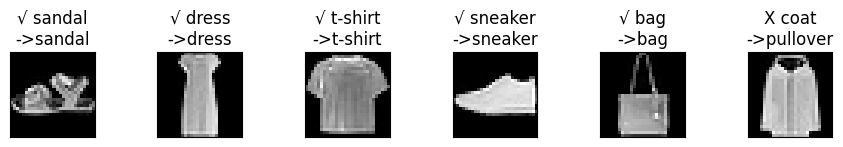

>>> 成功展示了 6 张样本


In [26]:
visualizer.show_next(6)

## 4.4 模型选择、欠拟合与过拟合

> 在深度学习中，模型并不是越复杂越好，我们的终极目标不是让模型在训练集上拿满分，而是让它在没见过的数据上表现良好。这种能力叫做泛化（Generalization）。

> 泛化的决定因素：
>   - 可训练参数的数量 (模型复杂性)。
>   - 参数的取值范围 (权重的大小)。
>   - 训练样本的数量 (数据越多，越难过拟合)。

### 1. 核心概念梳理

在进入代码实验前，我们需要统一三个核心术语的数学直觉：

#### (1) 训练误差 vs. 泛化误差
*   **训练误差 (Training Error)**：模型在训练数据集上的误差（相当于“开卷考试”的分数）。
*   **泛化误差 (Generalization Error)**：模型应用在同样分布但从未见过的新样本上的误差（相当于“正式考试”的分数）。
*   **工程目标**：我们通过最小化训练误差来拟合数据，但我们真正关心的是减小**泛化误差**。

#### (2) 欠拟合 (Underfitting)
*   **现象**：训练误差和验证误差都很高。
*   **本质**：模型太简单了（比如用直线去拟合曲线），或者训练时间太短，导致连训练集里的规律都没学会。
*   **对策**：增加模型复杂度（加隐藏层、加神经元）。

#### (3) 过拟合 (Overfitting)
*   **现象**：训练误差极低，但验证误差极高。
*   **本质**：模型太复杂或训练太久，把训练集里的“噪声”和“随机干扰”当成规律背下来了。
*   **对策**：减少模型复杂度、增加数据量、使用正则化或丢弃法。

#### (4) 完美拟合 (Sweet Spot)
*   **现象**：训练误差和泛化误差都处于较低水平，且两者差距较小。

---

### 2. 工程实践：模型选择与验证

为了在不接触“考试题（测试集）”的情况下挑选出最好的模型，我们需要一套科学的流程。

1.  **验证集（Validation Set）**：
    *   不要直接在测试集上调参！
    *   我们将数据分为：**训练集**（练题）、**验证集**（模拟考，用于调超参数）、**测试集**（高考，只准用一次）。
    *   实际上，验证集和测试集的边界模糊。而本学习中，大抵是没有真正的测试集，均为验证集。
2.  **K 折交叉验证（K-Fold Cross-Validation）**：
    *   当数据量太少，分不出独立的验证集时使用。
    *   将数据切成 K 份，轮流用 1 份做验证，K-1 份做训练，最后取平均分。

---

### 3. 实验设计：多项式回归

为了最直观地看到这三种状态，我们不再使用复杂的图像，而是回到最简单的**多项式回归**。
我们要拟合的真实公式是：
$$y = 5 + 1.2x - 3.4\frac{x^2}{2!} + 5.6\frac{x^3}{3!} + \epsilon$$

我们将尝试用不同阶数的模型去拟合它：
1.  **正常拟合**：用 3 阶多项式。
2.  **欠拟合**：强制只用 1 阶（线性）。
3.  **过拟合**：用 20 阶（极其复杂的模型）。

---


### 4. 实验代码实现

In [1]:
# 生成数据集
import math
import torch
from torch import nn, Tensor
import d2l_utils as d2l

def generate_poly_data(n_train: int = 100, n_test: int = 100) -> tuple[Tensor, Tensor, Tensor, Tensor]:
    """生成多项式数据集用于实验。
    
    真实模型: y = 5 + 1.2x -3.4(x^2/2!) + 5.6(x^3/3!) + noise

    Returns:
        tuple: (train_features, test_features, train_labels, test_labels)
    """
    max_degree = 20 # 多项式的最大阶数
    true_w = torch.zeros(max_degree) # 分配空间
    true_w[0:4] = torch.tensor([5, 1.2, -3.4, 5.6]) # 设定前4项系数

    # 生成随机 x, 形状为 (n_train + n_test, 1)
    features = torch.randn((n_train + n_test, 1))
    # 计算 x^0, x^1, x^2, ..., x^19
    # torch.pow(base, exponent): 计算 base^{exponent}
    poly_features = torch.pow(features, torch.arange(max_degree).float()) 
    # 归一化 (除以阶乘)，防止数值过大
    for i in range(max_degree):
        poly_features[:, i] /= math.gamma(i + 1)

    # 计算标签 y = Xw
    labels = torch.matmul(poly_features, true_w)
    labels += torch.normal(0, 0.1, size=labels.shape) # 加入噪声

    # 转换为列向量
    labels = labels.reshape((-1, 1))

    return (poly_features[:n_train, :], poly_features[n_train:, :],
            labels[:n_train, :], labels[n_train:, :])

# 获取数据
train_features, test_features, train_labels, test_labels = generate_poly_data()

In [ ]:
import d2l_utils as d2l
from typing import Callable
from torch.utils import data
# 定义训练评估函数
def evaluate_loss(net: nn.Module, data_iter: torch.utils.data.DataLoader, loss_fn: Callable) -> float:
    """评估模型在给定数据集上的平均损失。
    
    Args:
        net: 神经网络模型。
        data_iter: 数据加载器。
        loss_fn: 损失函数（如 nn.MSELoss）。

    Returns:
        平均损失值。
    """
    if isinstance(net, nn.Module):
        net.eval() # 设置为评估模式

    metric = d2l.Accumulator(2) # [损失总和, 样本总数]
    for X, y in data_iter:
        y_hat = net(X)
        l = loss_fn(y_hat, y)
        metric.add(l.sum().item(), l.numel())
    return metric[0] / metric[1]

def train_poly(
    train_features: Tensor,
    test_features: Tensor,
    train_labels: Tensor,
    test_labels: Tensor,
    num_epochs: int = 400,
    lr: float = 0.01
) -> tuple[float, float]:
    """多项式回归实验的训练逻辑封装。
    
    Args:
        train_features: 训练集特征。
        test_features: 测试集特征。
        train_labels: 训练集标签。
        test_labels: 测试集标签。
        num_epochs: 迭代轮数。
        lr: 学习率 (步长)。

    Returns:
        (最终训练误差, 最终测试误差)。
    """
    loss_fn = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]

    # 定义简单的线性层作为模型
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])

    train_iter = data.DataLoader(
        data.TensorDataset(train_features, train_labels),
        batch_size, shuffle=True
    )

    test_iter = data.DataLoader(
        data.TensorDataset(test_features, test_labels),
        batch_size, shuffle=False
    )

    trainer = torch.optim.SGD(net.parameters(), lr=lr)

    for epoch in range(num_epochs):
        net.train()
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss_fn(net(X), y)
            l.mean().backward()
            trainer.step()

    train_l = evaluate_loss(net, train_iter, loss_fn)
    test_l = evaluate_loss(net, test_iter, loss_fn)
    return train_l, test_l

### 三种情景实战

In [4]:
# --- 实验 1: 正常拟合 ---
# 我们只给模型前 4 个特征 (x^0 到 x^3)
l_train, l_test = train_poly(train_features[:, :4], test_features[:, :4], train_labels, test_labels)
print(f"[正常] 训练误差: {l_train:.4f}, 测试误差: {l_test:.4f}")

# --- 实验 2: 欠拟合 ---
# 真实规律是 3 阶，但我们只给模型 1 阶特征 (x^0, x^1)
l_train, l_test = train_poly(train_features[:, :2], test_features[:, :2], train_labels, test_labels)
print(f"[欠拟合] 训练误差: {l_train:.4f}, 测试误差: {l_test:.4f}")

# --- 实验 3: 过拟合 --- 
# 特征给足 20 阶，但训练样本只给 20 个（故意减少数据）
l_train, l_test = train_poly(train_features[:20, :], test_features[:, :], train_labels[:20], test_labels[:])
print(f"[过拟合] 训练误差: {l_train:.4f}, 测试误差: {l_test:.4f}")

[正常] 训练误差: 0.0095, 测试误差: 0.0134
[欠拟合] 训练误差: 8.1116, 测试误差: 12.6254
[过拟合] 训练误差: 0.3551, 测试误差: 1.9499


## 4.5 权重衰减 (Weight Decay)

> 在数学界，它被称为 L2 正则化（L2 Regularization）。

### 1. 核心动机：对抗过拟合
在深度学习中，**过拟合 (Overfitting)** 的典型特征是：训练误差极低，但泛化误差（测试误差）极高。
*   **数学直觉**：过拟合的模型通常具有极其复杂的函数曲线，这需要巨大的权重数值 $\mathbf{w}$ 来支撑在噪声点间的剧烈波动。
*   **解决思路**：通过限制权重的大小，强迫模型变得更“简单（平滑）”。这种技术被称为**正则化 (Regularization)**。

---

### 2. 数学原理：L2 正则化

#### 2.1 目标函数
我们在原始损失函数 $L(\mathbf{w}, b)$ 的基础上，增加一个**惩罚项**：
$$\tilde{L}(\mathbf{w}, b) = L(\mathbf{w}, b) + \frac{\lambda}{2} \|\mathbf{w}\|^2$$
*   **$\lambda$ (超参数)**：正则化常数。$\lambda=0$ 时无正则化；$\lambda$ 越大，对权重的压制越狠。
*   **$\|\mathbf{w}\|^2$**：L2 范数的平方（即 $w_1^2 + w_2^2 + \dots$）。
*   **$1/2$**：为了在求导时抵消平方项产生的系数 2。

#### 2.2 为什么叫“权重衰减”？
观察梯度下降的更新公式：
1.  **计算梯度**：$\frac{\partial \tilde{L}}{\partial \mathbf{w}} = \frac{\partial L}{\partial \mathbf{w}} + \lambda \mathbf{w}$
2.  **更新权重**：$\mathbf{w}_{t+1} = \mathbf{w}_t - \eta (\frac{\partial L}{\partial \mathbf{w}_t} + \lambda \mathbf{w}_t)$
3.  **整理公式**：$\mathbf{w}_{t+1} = \mathbf{(1 - \eta\lambda)} \mathbf{w}_t - \eta \frac{\partial L}{\partial \mathbf{w}_t}$

**结论**：每次更新前，权重都会先乘以一个小于 1 的系数 $(1 - \eta\lambda)$。这意味着权重在没有强大梯度拉回的情况下，会自然地向 0 **衰减**。

---

### 3. L1 vs L2 正则化：本质对决

| 特性 | L1 正则化 (Lasso) | L2 正则化 (Ridge) |
| :--- | :--- | :--- |
| **数学形式** | $ \lambda \sum \lvert w_i \rvert $ | $ \frac{\lambda}{2} \sum w_i^2 $ |
| **梯度压力** | **恒定压力**：只要不是 0，梯度永远是 $\pm \lambda$。 | **比例压力**：压力随权重变小而减弱。 |
| **物理效果** | **稀疏性 (Sparsity)**：倾向于让权重精准归零。 | **平滑性 (Smoothness)**：倾向于让权重变小但不为 0。 |
| **几何形状** | 约束空间是带尖角的“菱形”。 | 约束空间是平滑的“圆形”。 |
| **工程角色** | **剪枝刀**：用于特征选择和模型压缩。 | **磨刀石**：用于稳定训练和增强泛化能力。 |

---

### 4. 模型选择与评估流程 (Model Selection)

为了科学地选择正则化强度 $\lambda$，必须遵循以下规范：

1.  **验证集 (Validation Set)**：严禁使用测试集调参。训练集练权重，验证集选 $\lambda$。
2.  **K 折交叉验证 (K-Fold)**：数据量小时，将数据均分 $K$ 份，轮流用 1 份验证，$K-1$ 份训练，取平均表现。
3.  **纯净评估 (Pure Evaluation)**：评估模型时，必须剥离正则项。指标（如 MSE）应只反映预测误差，不含人为的惩罚分。

---

### 5. 关键工程暗知识 (Engineering Wisdom)

1.  **不正则化偏置 (Bias)**：偏置项仅控制函数的平移，不增加函数的复杂抖动。对偏置进行正则化通常无助于解决过拟合，反而可能导致欠拟合。
2.  **验证集评估**：评估模型性能时，必须使用**纯净的损失函数**（不含 $\lambda$ 项）。正则化项只是训练时的“脚手架”，衡量模型好坏的唯一标准是它在原始数据上的预测精度。
3.  **W-Norm 监控**：在训练日志中监控权重的 **L2 范数**。如果 $\lambda$ 生效，你会观察到 `W-Norm` 迅速下降并保持在较低水平。
4.  **统计一致性**：在计算平均损失时，无论 `reduction` 模式如何，都应先还原为 Batch 总损失再进行累加，以消除最后一个不满额 Batch 带来的偏差。

---

### 6. 总结
**权重衰减（L2 正则化）** 是深度学习中最基础也最强大的工具。它通过在优化目标中加入对“大权重”的惩罚，实现了模型精度与复杂度之间的平衡。理解了 L1 的稀疏性和 L2 的平滑性，你就能在面对不同业务场景时，从数学底层做出正确的架构选择。


In [3]:
# 生成数据集
import torch
from torch import nn, Tensor
from torch.utils import data
from torch.utils.data import DataLoader
from typing import Callable, Union

def generate_overfit_data(
    n_train: int = 20,
    n_test: int = 100,
    num_inputs: int = 200
) -> tuple[Tensor, Tensor, Tensor, Tensor]:
    """生成一个容易导致过拟合的高维线性数据集。
    
    Args:
        n_train: 训练样本数。
        n_test: 测试样本数。
        num_inputs: 特征维度。

    Returns:
        包含 (train_features, test_features, train_labels, test_labels) 的元组。
    """
    true_w: Tensor = torch.ones((num_inputs, 1)) * 0.01
    true_b: float = 0.05

    features: Tensor = torch.randn((n_train + n_test, num_inputs))
    labels: Tensor = torch.matmul(features, true_w) + true_b
    labels += torch.normal(0, 0.01, labels.shape)

    return (features[:n_train, :], features[n_train:, :],
            labels[:n_train], labels[n_train:])

评估函数评估的是“预测质量”，而非“训练约束”。故不应该携带惩罚项。

*   **训练时**：我们给模型戴上“枷锁”（正则项），是为了防止它通过把权重变得巨大来走捷径（过拟合）。此时 Loss = $Loss_{数据} + Loss_{惩罚}$。
*   **评估时**：我们想看的是模型在没见过的数据上**猜得准不准**。

In [4]:
import d2l_utils as d2l
# 评估函数
@torch.no_grad()
def evaluate_loss_general(
    net: Callable[[Tensor], Tensor],
    data_iter: DataLoader,
    loss_fn: Callable[[Tensor, Tensor], Tensor]
) -> float:
    """通用的损失评估函数。
    
    该函数计算模型在给定数据集上的平均损失。它会自动处理 nn.Module 的评估模式切换，
    并确保计算过程中不产生梯度，以节省内存和算力。

    Args:
        net: 模型前向传播函数或 nn.Module 实例 (即神经网络)。
        data_iter: 待评估的数据加载器。
        loss_fn: 损失函数（建议传入不带正则项的原始损失，如 MSELoss）。
    """
    # 1. 状态切换: 如果是 nn.Module，进入评估模式 (对 Dropout/BatchNorm 关键)
    if isinstance(net, nn.Module):
        net.eval()

    # 2. 初始化账本: [损失总和, 样本总数]
    metric = d2l.Accumulator(2)

    for X, y in data_iter:
        # 3. 前向传播
        y_hat = net(X)
        l = loss_fn(y_hat, y)

        # 4. 损失值规范化处理
        # 无论 loss_fn 的 reduction 是 'mean' 还是 'none'，都还原为该 batch 的总损失。
        # 逻辑: 总损失 = 平均值 * 样本数 (如果是 'mean') 或 sum() (如果是 'none')
        if hasattr(loss_fn, 'reduction') and loss_fn.reduction == 'mean':
            batch_loss_sum = l.item() * y.numel()
        else:
            batch_loss_sum = l.sum().item()

        metric.add(batch_loss_sum, y.numel())

    # 5. 返回全局平均损失
    return metric[0] / metric[1]

In [5]:
# 可视化监控工具
import matplotlib.pyplot as plt
from typing import Optional
def plot_training_history(
    train_losses: list[float],
    test_losses: list[float],
    title: str = "Training and Test Loss",
    xlabel: str = "Epochs",
    ylabel: str = "Loss",
    yscale: str = "log"
) -> None:
    """绘制训练与测试损失曲线。
    
    通过对比两条曲线的走势，可以直观判断模型状态：
    - 两线均高：欠拟合 (Underfitting)
    - 训练线下滑，测试线持平或上升：过拟合 (Overfitting)
    - 两线均低且接近：理想状态 (Sweet Spot)

    Args:
        train_losses: 每一轮训练损失的历史记录。
        test_losses: 每一轮测试损失的历史记录。
        title: 图表标题。
        xlabel: X 轴标签 (通常是迭代轮数)。
        ylabel: Y 轴标签 (通常是损失值)。
        yscale: 轴的缩放类型，"linear" 或 "log"。多项式实验建议用 "log"。
    """
    plt.close()
    plt.figure(figsize=(6, 4))

    # x 轴对齐
    train_epochs = range(1, len(train_losses) + 1)
    if len(test_losses) > 0:
        step = len(train_losses) // len(test_losses)
        test_epochs = [i * step for i in range(1, len(test_losses) + 1)]
    else:
        test_epochs = []

    # plt.plot(x轴, y轴, 曲线图例, 线条样式, 数据点标记符)
    plt.plot(train_epochs, train_losses, label="Train loss", linestyle="--", marker="o", markersize=3)
    if test_epochs:
        plt.plot(test_epochs, test_losses, label="Test loss", linestyle="-", marker="v", markersize=5)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.yscale(yscale)
    plt.title(title)
    plt.legend()

    # 添加网格背景方便读取数据
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.tight_layout()
    plt.show()

无论是什么模型，训练循环的本质都是：
`获取数据` -> `前向传播` -> `计算损失` -> **`执行更新`** -> `记录结果`。



In [6]:
# 通用训练引擎
def train_wd_epoch(
    net: Callable[[Tensor], Tensor],
    train_iter: DataLoader,
    loss_fn: Callable[[Tensor, Tensor], Tensor],
    updater: Union[torch.optim.Optimizer, Callable[[int], None]]
) -> float:
    """通用的单轮训练引擎，支持权重衰减逻辑。
    
    Args:
        net: 模型前向传播函数或 nn.Module (即神经网络)。
        train_iter: 训练数据迭代器。
        loss_fn: 损失函数。
        updater: 优化器(可以是 PyTorch 官方优化器或者自定义的 sgd 函数)。

    Returns:
        本轮的平均训练损失。
    """
    metric = d2l.Accumulator(2) # (loss_sum, sample_count)

    if isinstance(net, nn.Module):
        net.train()

    for X, y in train_iter:
        # 1. 前向传播。
        y_hat = net(X)
        l = loss_fn(y_hat, y)

        # 2. 计算当前批次的 “总损失数值” 用于统计。
        batch_size = X.shape[0]
        if l.numel() == 1:
            # 标量张量：检查是否需要乘以 batch_size
            if hasattr(loss_fn, 'reduction') and loss_fn.reduction == 'mean':
                # 情况 A: reduction = 'mean'
                batch_loss_sum = l.item() * batch_size
            else:
                # 情况 B: 这是总损失（reduction='sum' 或其他自定义标量）
                batch_loss_sum = l.item()
        else:
            # 向量张量：总是求和。
            # 情况 C: reduction = 'none' (手动实现默认是 'none')
            batch_loss_sum = l.sum().item()

        # 3. 反向传播与参数更新
        if isinstance(updater, torch.optim.Optimizer):
            # 简洁实现逻辑
            updater.zero_grad()
            if hasattr(loss_fn, 'reduction') and loss_fn.reduction == 'none':
                # 情况 A: reduction = 'none'
                l.mean().backward()
            elif hasattr(loss_fn, 'reduction') and loss_fn.reduction == 'mean':
                # 情况 B: reduction = 'mean'
                l.backward()
            else:
                # 情况 C: reduction = 'sum'
                (l / batch_size).backward() # 强制转为平均梯度以适配官方优化器
            updater.step()
        
        else:
            # 从零实现逻辑
            # 用的是之前写的 sgd(batch_size) 函数
            l.sum().backward()
            updater(batch_size)

        # 4. 记录数据
        metric.add(batch_loss_sum, batch_size)

    return metric[0] / metric[1]

def train_wd(
    net: Callable[[Tensor], Tensor],
    train_iter: DataLoader,
    test_iter: DataLoader,
    loss_fn: Callable[[Tensor, Tensor], Tensor],
    num_epochs: int,
    updater: Union[torch.optim.Optimizer, Callable[[int], None]],
    weight_monitor_fn: Callable[[], Tensor]
) -> tuple[list[float], list[float]]:
    """多轮训练函数，具备权重范数监测功能。
    
    该函数负责协调完整的训练生命周期，包括调用单轮训练引擎进行参数更新、定期在测试集上
    评估模型的泛化性能，以及监控模型权重的 L2 范数。通过监控权重范数，开发者可以直观
    地观察到权重衰减（L2 正则化）对模型复杂度的抑制效果。

    Args:
        net: 神经网络模型。
        train_iter: 训练集的数据加载器，用于提供分批次的训练数据。
        test_iter: 验证集的数据加载器，用于衡量模型在未见数据上的表现。
        loss_fn: 损失函数。接收预测张量和目标张量，返回损失值。需注意其 "reduction" 设置应与 updater 的预期一致。
        num_epochs: 训练的总迭代周期 (epoch) 数量。
        updater: 参数更新器。支持两种模式：
            1. torch.optim.Optimizer 实例（如官方 SGD），通常预期平均梯度。
            2. 自定义函数（如从零实现的 sgd），接收当前批次的实际样本数 batch_size 作为输入。
        weight_monitor_fn: 权重检测回调函数。不接收参数，返回当前模型核心权重参数的 
            L2 范数 (float)。该指标是判断过拟合是否得到缓解的关键数学依据。

    Returns:
        - 返回 (train_loss_history, test_loss_history)。
        - 训练指标和权重状态将定期输出至标准控制台。

    Example:
        >>> get_w_norm = lambda: net[0].weight.norm().item()
        >>> train_wd_engine(net, train_iter, test_iter, loss_fn, 100, trainer, get_w_norm)
    """
    # print(f"开始训练，总轮数: {num_epochs}。")
    train_loss_history: list[float] = []
    test_loss_history: list[float] = []

    for epoch in range(num_epochs):
        # 1. 执行一轮训练
        train_loss = train_wd_epoch(net, train_iter, loss_fn, updater)
        train_loss_history.append(train_loss)

        # 2. 定期评估与监控 (每 20 轮执行一次，减少频繁评估带来的计算开销)
        # 如果想要画出精细曲线，可考虑每一轮都记录。
        if (epoch + 1) % 20 == 0:
            # 调用评估函数，确保在 eval 模式下进行。
            test_loss = evaluate_loss_general(net, test_iter, loss_fn)
            test_loss_history.append(test_loss)

            # 获取当前权重的 "长度"，这是 L2 正则化效果的直接指标。
            current_w_norm = weight_monitor_fn()

            # 3. 打印当前轮次的进度
            print(f"Epoch {epoch + 1: 4d}: "
                  f"Train Loss {train_loss:.4f}, "
                  f"Test Loss {test_loss:.4f}, "
                  f"W-Norm {current_w_norm:.4f}")
            
    return train_loss_history, test_loss_history

In [7]:
# 定义配置类
# 暂时仅针对 权重衰减 实验。
from dataclasses import dataclass

@dataclass(frozen=True)
class ExperimentConfig:
    """深度学习实验超参数配置类。
    
    使用 dataclass 确保类型安全和 IDE 自动补全。
    frozen=True 保证配置在初始化后不能修改，符合函数式编程规范。
    """
    # 数据集相关
    num_inputs: int = 200       # 特征向量维数
    num_outputs: int = 1        # 输出维度

    # 训练循环相关
    num_epochs: int = 100       # 训练循环数
    lr: float = 0.003           # 学习率
    batch_size: int = 64        # 一轮训练的训练量

    # 正则化相关
    wd: float = 0.0             # 权重衰减系数 weight_decay (有时也写作 lambda)

    def __post_init__(self):
        """参数校验逻辑。"""
        if self.lr <= 0:
            raise ValueError(f"学习率必须大于0,当前为: {self.lr}。")

**原理**：$L_{total} = L_{data} + \frac{\lambda}{2}w^2$。求导时，$\frac{d}{dw}(\frac{\lambda}{2}w^2) = \lambda w$。

习惯上，手写代码的“权重衰减系数”应该写成 "lamdb"，但为了保证字段统一(懒得在配置文件里多一个字段)，故本文件用 wd 直接作为手写代码的“权重衰减系数”变量名。

值得注意的是，虽然在 **SGD（随机梯度下降）** 优化器中，`weight_decay` 和 L2 正则化是完全等价的，但在一些复杂的优化器（如 **Adam**）中，两者是有区别的：

1.  **L2 正则化**：是在计算梯度**之前**，把惩罚项加进 Loss 里。
2.  **权重衰减 (Weight Decay)**：是在计算完梯度**之后**，直接让权重乘以一个衰减系数。

*   **后果**：在 Adam 优化器中，直接加 L2 惩罚的效果往往不如直接做权重衰减好。
*   **工程结论**：为了修复这个问题，后来出现了 **AdamW** 优化器（W 就代表 Weight Decay）。在 PyTorch 中，我们现在几乎总是首选 AdamW 而不是 Adam。



In [8]:
# 权重衰减的从零实现
def l2_penalty(w: Tensor) -> Tensor:
    """计算 L2 范数惩罚项(1/2 * ||w||^2)。
    
    使用平方和除以 2，是为了在求导时抵消掉平方项产生的系数 2。

    Args: 
        w: 需要计算惩罚项的权重张量。

    Returns:
        Tensor: 标量惩罚项。
    """
    return torch.sum(w.pow(2)) / 2

def run_scratch_experiment(wd: float, config: ExperimentConfig, train_iter: DataLoader, test_iter: DataLoader):
    """从零实现权重衰减实验。
    
    Args:
        wd: 权重衰减系数 (wd)。
        config: 包含训练超参数的配置类。
            需包含: "num_inputs", "lr", "num_epochs"。
    """
    # 0. 配置参数解析。
    num_inputs: int = config.num_inputs
    num_outputs: int = config.num_outputs
    lr: float = config.lr
    num_epochs = config.num_epochs

    # 1. 参数初始化
    # w 初始化为均值为 0，标准差为 1 的正态分布；b 初始化为 0
    w = torch.normal(0, 1, size=(num_inputs, num_outputs), requires_grad=True)
    b = torch.zeros(num_outputs, requires_grad=True)

    # 2. 核心逻辑定义

    def net(X: Tensor) -> Tensor:
        """线性回归模型前向传播: y = Xw + b。"""
        return X @ w + b
    
    def loss_with_wd(y_hat: Tensor, y: Tensor) -> Tensor:
        """带 L2 惩罚项的损失函数。
        
        数学公式：Loss = MSE(y_hat, y) + lambda(对应 wd) * (1/2 * ||w||^2)
        """
        # 计算基础均方误差 (MSE)
        mse = (y_hat - y.reshape(y_hat.shape))**2 / 2
        # 将惩罚项加到基础损失上
        return mse + wd * l2_penalty(w)

    def updater_fn(batch_size: int) -> None:
        """参数更新函数。
        
        调用自定义的 sgd 函数来更新手动管理的 w 和 b。
        """
        d2l.sgd([w, b], lr, batch_size)

    # 权重监控函数：实时测量 w 的 "长度"
    get_w_norm = lambda: torch.norm(w).item()

    # 3. 开始训练
    print(f"\n[Scratch] 启动实验 | WD: {wd} | LR: {lr} | Epochs: {num_epochs}")
    train_loss_history, test_loss_history = train_wd(
        net=net,
        train_iter=train_iter,
        test_iter=test_iter,
        loss_fn=loss_with_wd,
        num_epochs=num_epochs,
        updater=updater_fn,
        weight_monitor_fn=get_w_norm
    )

    plot_training_history(
        train_losses=train_loss_history,
        test_losses=test_loss_history,
        title=f"L2 Regularization (Weight Decay = {wd})",
        yscale="log"
    )

In [9]:
# 权重衰减的简洁实现
def run_concise_experiment(wd: float, config: ExperimentConfig, train_iter: DataLoader, test_iter: DataLoader) -> None:
    """简洁实现权重衰减实验。
    
    Args:
        wd: 权重衰减系数 (weight_decay)。
        config: 包含超参数的 ExperimentConfig 类实例。
    """
    # 0. 解析配置
    num_inputs: int = config.num_inputs
    num_outputs: int = config.num_outputs
    lr: float = config.lr
    num_epochs: int = config.num_epochs

    # 1. 核心组件
    def get_wd_net(num_inputs: int, num_outputs: int) -> nn.Sequential:
        """构建 weight decay 实验模型。
        
        Args:
            num_inputs: 输入特征维度。
            num_outputs: 输出维度（线性回归是 1 维）。

        Returns:
            包含线性层的顺序模型。
        """
        net = nn.Sequential(nn.Linear(num_inputs, num_outputs))

        # 初始化权重
        # 写成嵌套函数的原因：命名空间保护 与 逻辑紧凑需求。
        def init_weights(m: nn.Module) -> None:
            if type(m) == nn.Linear:
                # 使用均值为 0，标准差为 1.0 的正态分布初始化权重
                nn.init.normal_(m.weight, std=1.0)
                # 偏置初始化为 0
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

        # apply 函数会递归地对 net 里的每一层执行 init_weights
        net.apply(init_weights)
        return net
    
    net = get_wd_net(num_inputs=num_inputs, num_outputs=num_outputs)
    loss_fn = nn.MSELoss(reduction='none')

    # 配置参数分组：w 衰减，b 不衰减
    # net[0] 指向 Linear 层
    params_to_optimize = [
        # 第一组：权重 w
        {"params": net[0].weight, "weight_decay": wd},
        # 第二组：权重 b
        {"params": net[0].bias}
    ]
    trainer = torch.optim.SGD(params_to_optimize, lr=lr)
    get_w_norm = lambda: net[0].weight.norm().item()

    # 2. 开始训练
    print(f"\n[Concise] 启动实验 | WD: {wd} | LR: {lr} | Epochs: {num_epochs}")
    train_loss_history, test_loss_history = train_wd(
        net=net,
        train_iter=train_iter,
        test_iter=test_iter,
        loss_fn=loss_fn,
        num_epochs=num_epochs,
        updater=trainer,
        weight_monitor_fn=get_w_norm
    )

    plot_training_history(
        train_losses=train_loss_history,
        test_losses=test_loss_history,
        title=f"L2 Regularization (Weight Decay = {wd})",
        yscale="log"
    )


[Scratch] 启动实验 | WD: 0.0 | LR: 0.003 | Epochs: 100
Epoch   20: Train Loss 1.4481, Test Loss 85.2230, W-Norm 13.2896
Epoch   40: Train Loss 0.0527, Test Loss 85.7914, W-Norm 13.2765
Epoch   60: Train Loss 0.0025, Test Loss 85.8499, W-Norm 13.2759
Epoch   80: Train Loss 0.0001, Test Loss 85.8558, W-Norm 13.2758
Epoch  100: Train Loss 0.0000, Test Loss 85.8563, W-Norm 13.2758


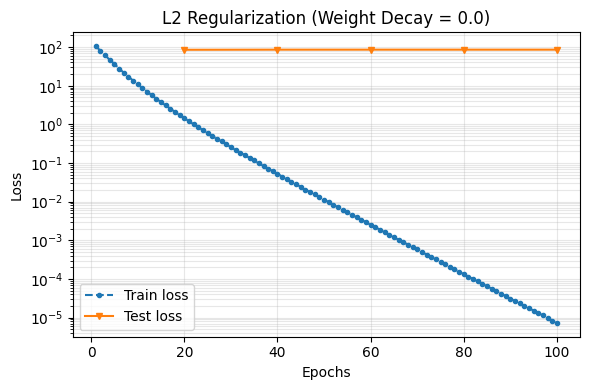


[Scratch] 启动实验 | WD: 3.0 | LR: 0.003 | Epochs: 100
Epoch   20: Train Loss 67.2069, Test Loss 86.4994, W-Norm 6.5224
Epoch   40: Train Loss 15.6895, Test Loss 20.2764, W-Norm 3.1611
Epoch   60: Train Loss 3.6940, Test Loss 4.7675, W-Norm 1.5339
Epoch   80: Train Loss 0.8713, Test Loss 1.1297, W-Norm 0.7448
Epoch  100: Train Loss 0.2069, Test Loss 0.2790, W-Norm 0.3626


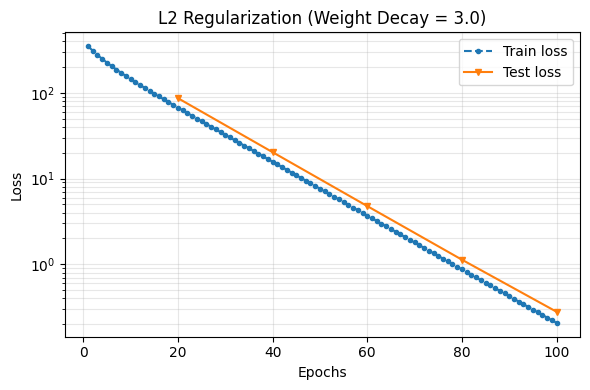


[Concise] 启动实验 | WD: 3.0 | LR: 0.003 | Epochs: 100
Epoch   20: Train Loss 0.0088, Test Loss 49.7246, W-Norm 7.0941
Epoch   40: Train Loss 0.0029, Test Loss 11.7851, W-Norm 3.4430
Epoch   60: Train Loss 0.0027, Test Loss 2.8326, W-Norm 1.6729
Epoch   80: Train Loss 0.0025, Test Loss 0.7194, W-Norm 0.8160
Epoch  100: Train Loss 0.0022, Test Loss 0.2162, W-Norm 0.4040


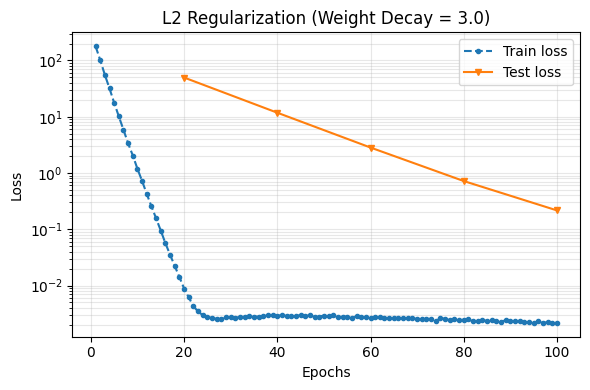

In [10]:
# 统一配置参数
BASE_CONFIG = ExperimentConfig(
    num_inputs = 200,
    num_outputs = 1,
    num_epochs = 100,
    lr = 0.003,
    batch_size = 5
)

# 准备数据
train_features, test_features, train_labels, test_labels = generate_overfit_data()
train_iter = data.DataLoader(
    data.TensorDataset(train_features, train_labels),
    BASE_CONFIG.batch_size, shuffle=True
)

test_iter = data.DataLoader(
    data.TensorDataset(test_features, test_labels),
    BASE_CONFIG.batch_size, shuffle=False
)

# 执行对比
# 官方大抵是表现的更好的，因为官方的 MSE 没有 1/2 的系数。
run_scratch_experiment(wd=0.0, config=BASE_CONFIG, train_iter=train_iter, test_iter=test_iter)      # 无正则化：严重过拟合
run_scratch_experiment(wd=3.0, config=BASE_CONFIG, train_iter=train_iter, test_iter=test_iter)      # 有正则化：测试误差显著改善
run_concise_experiment(wd=3.0, config=BASE_CONFIG, train_iter=train_iter, test_iter=test_iter)      # 简洁实现：效果一致

## 附录：超参数

在深度学习中，**超参数（Hyperparameters）** 是一个非常核心的概念。

简单一句话总结：**“参数”是模型自己通过学习（反向传播）算出来的；而“超参数”是你（程序员）在训练开始前手动设定好的。**

---

### 1. 核心对比
*   **参数** ($w, b$)：模型**自己学**出来的（通过 `backward` 自动更新）。
*   **超参数**：你**帮模型选**的（决定模型怎么学、学多快）。

---

### 2. 深度对比：参数 vs. 超参数

| 特性 | 参数 (Parameters) | 超参数 (Hyperparameters) |
| :--- | :--- | :--- |
| **谁来决定** | **模型自己**通过数据学习 | **算法工程师**手动指定 |
| **何时确定** | 训练过程中不断更新 | 训练开始前就固定好 |
| **代表例子** | 权重 $w$、偏置 $b$ | 学习率、Batch Size、隐藏层神经元个数 |
| **存储位置** | `param.data` | 超参数通常出现在最顶层，作为全局配置（如 `lr = 0.1`） |
| **目标** | 最小化 Loss | 寻找最优的训练配置 |

---

### 3. 常见的超参数清单（本章涉及的）

| 超参数 | 含义 |
| :--- | :--- |
| **`lr`** (学习率) | 每次更新参数时迈的步子有多大。 |
| **`batch_size`** | 每次计算梯度时“看”多少张图片。 |
| **`num_epochs`** | 让模型把整套数据集从头到尾看几遍。 |
| **`num_hiddens`** | 隐藏层里放多少个神经元（模型的“脑容量”）。 |
| **`wd`** (权重衰减系数) | 控制对权重大小的惩罚力度（L2 正则化），用于防止过拟合。 |

---

### 4. 工程实践：如何调超参数？

寻找最优超参数的过程叫 **“调参” (Hyperparameter Tuning)**。在工业界，这通常有三种方法：
1.  **凭经验 (Intuition)**：比如 Fashion-MNIST 这种规模，`lr=0.1` 或 `0.01` 通常是安全的。
2.  **网格搜索 (Grid Search)**：尝试所有组合（比如 `lr` 选 [0.1, 0.01]，`batch_size` 选 [64, 128]，排列组合都试一遍）。
3.  **随机搜索 (Random Search)**：在一定范围内随机乱试（通常比网格搜索更高效）。

**一句话总结：参数决定“模型是什么”，超参数决定“模型怎么练”。**
